# Getting Started

Make sure to follow all instructions in the [Quick Start](../../README.md#quick-start) section before continuing 

### Import All Necessary Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sys
import seaborn as sns

from scipy.stats import uniform, multivariate_normal

from smcpy.mcmc.vector_mcmc import VectorMCMC
from smcpy.mcmc.vector_mcmc_kernel import VectorMCMCKernel
from smcpy import FixedSampler as Sampler
from smcpy.paths import GeometricPath
from examples.helper_functions import eval_model, generate_data, plot_posterior

# Key Takeaways

From this tutorial we will learn:
- how to create a custom proposal distribution
- how to apply the proposal distribution to SMCPy

# What is a Proposal?
A proposal is an **optional** distribution that is defined by the user that will be used to calculate the target distribution in SMCPy. When running SMCPy with a proposal distribution, the target distribution is now calculated slightly different:

**<u>NEW Target Distribution</u>** <br />
$$P_t(\theta | D) = P(D | \theta)^{\phi_t} P(\theta)^{\alpha} G(\theta)^{\beta}$$

Where $\phi_t$ is part of the increasing phi sequence,
$$[0, \dots, \phi_t, \dots, 1]$$

**<u>Key</u>** <br />
New:
- $G(\theta)^{\beta} =$ Proposal
- $\alpha = min(1, \phi_t)$
- $\beta = max(0, 1 - \phi_t)$ 

Old:
- $\phi_t$ = value between $[0, 1]$
- $t = 1, 2, \dots, T$
- $T$ = the total length of the $\phi$ sequence.

Note based on the target distribution equation, this means that: <br />
$\phi_t$ = 0 means that the taret distribution is NOT influenced by the **prior** <br />
$\phi_t$ = 1 means that the target distribution is NOT influenced by the **proposal** 

### Proposals VS Priors
Both priors and proposals are distributions that are defined by the user to calculate the target distribution. As the $\phi_t$ value increases throughout the SMC run, our proposal will have a weaker influence when calculating our target distribution. The prior on the other hand will have an increasing amount of influence in the calculation. 

### Why are Proposals Important?
There are situations where calculating the target distribution of particles based on our prior is difficult. 

An example would be a prior with a uniform distribution that ranges from $[-\infty, \infty]$. Our particles for the initial random sample could land anywhere from that range! This can significantly increase the amount of iterations needed to get to our posterior distribution in situations where the particles are landing far away from the calculated target distribution. In cases like this, we can define a proposal distribution to help guide the target distribution towards the posterior distribution while still applying our prior distribution in our calculations.

# Example Problem
For this example we will use the same linear model and true parameter values from the linear example problem across $x_i = [0, 99]$:
$$y_i = Ax_i + B$$ 

True Parameter Values:
- $A = 2$
- $B = 3.5$

# Setting Up SMC Sampler WITHOUT Proposal
This is the basic SMC setup as the one in the [linear model tutorial](../simple_example/run_example_adaptive.ipynb).

In [2]:
STD_DEV = 2
X_TRUE = np.array([[2, 3.5]])
NUM_PARTICLES = 500

np.random.seed(200)
noisy_data = generate_data(X_TRUE, eval_model, STD_DEV, plot=False)
priors = [uniform(-5, 10), uniform(-10, 20)]
vector_mcmc = VectorMCMC(eval_model, noisy_data, priors, STD_DEV)
phi_sequence = np.linspace(0, 1, 20)

# initialize from prior
mcmc_kernel = VectorMCMCKernel(vector_mcmc, param_order=("a", "b"))
smc = Sampler(mcmc_kernel)
reg_step_list, mll_list = smc.sample(
    num_particles=NUM_PARTICLES,
    num_mcmc_samples=5,
    phi_sequence=phi_sequence,
    ess_threshold=1.0,
    progress_bar=True,
)


t: 20 | ess:   499.04 | mut. ratio: 99.2% | resample: True |: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:05<00:00,  3.17it/s]


# Setting up SMC Sampler WITH Proposal

### Creating the Proposal Distribution

When defining our proposal distribution, make sure to define this **before** creating our `VectorMCMCKernel`. 

Below we define our proposal distribution as a multivariate normal distribution with means $A = 2$ and $B = 3$ and a standard deviation of $\sigma = 1$ for both parameters. 


In [3]:
# initialize from proposal
proposal_dist = multivariate_normal(mean=np.array([2, 3]), cov=np.eye(2))
    

### Applying the Proposal Distribution in SMC


To apply our proposal distribution, we need to provide the `proposal` argument in the `GeometricPath` object with our proposal distribution.

In [4]:
proposal_path = GeometricPath(proposal=proposal_dist)

We will then apply this into the `path` argument in `VectorMCMCKernel`.

In [5]:
mcmc_kernel = VectorMCMCKernel(
    vector_mcmc, param_order=("a", "b"), path=proposal_path
)

### Running the SMC Sampler

Now we can run our sampler as per usual.

In [6]:
smc = Sampler(mcmc_kernel)
prop_step_list, mll_list = smc.sample(
    num_particles=NUM_PARTICLES,
    num_mcmc_samples=5,
    phi_sequence=phi_sequence,
    ess_threshold=1.0,
    progress_bar=True,
)


t:  1 | ess:      nan | mut. ratio: 100.0% | resample: False |:   0%|                                                                                                                                                          | 0/19 [00:00<?, ?it/s]

t: 20 | ess:   156.21 | mut. ratio: 99.4% | resample: True |: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:05<00:00,  3.17it/s]


### Comparing SMCPy Runs: With Prior Distribution  VS Without Prior Distribution

Using our particle results from both of the SMCPy runs, the graph below plots the mean parameter values for both $A$ and $B$ throughout each iteration. We see that...

In [7]:
def plot_posterior(step_list, out_file_base, show_mcmc=False, figsize=None):
    for param_idx, param in enumerate(step_list[-1].param_dict.keys()):
        title = (
            "Without Proposal: " if "without" in out_file_base else "With Proposal: "
        )
        out_file = out_file_base + f"_{param}.png"

        phi_seq = np.array([])
        for phi in step_list.phi_sequence:
            phi_lst = ["%.3f" % (phi)] * step_list[-1].num_particles
            phi_seq = np.hstack((phi_seq, phi_lst))

        param_vals = np.array([])
        for step in step_list:
            param_vals = np.hstack((param_vals, step.params[:, param_idx]))

        data = pd.DataFrame({"phi": phi_seq, param: param_vals})

        # lower_bound = 1.8
        # data = data[data.apply(param) >= lower_bound]
        sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
        pal = sns.color_palette("crest", n_colors=len(data.phi.unique()))
        g = sns.FacetGrid(
            data,
            row="phi",
            hue="phi",
            aspect=15,
            height=0.5,
            palette=pal,
            sharex=True,
            sharey=False,
        )

        def custom_kdeplot(data, color, **kwargs):
            bw = 0.5  # Default bandwidth
            if data["phi"].iloc[0] == "MCMC":  # Adjust for last facet
                bw = 2.5  # Change bw_adjust for last facet
            sns.kdeplot(
                data=data,
                x=param,
                bw_adjust=bw,
                clip_on=False,
                fill=True,
                alpha=1,
                linewidth=1.5,
                color=color,
            )
            sns.kdeplot(
                data=data, x=param, bw_adjust=bw, clip_on=False, color="w", lw=2
            )

        g.map_dataframe(custom_kdeplot)

        g.refline(y=0, linewidth=1, linestyle="-", color=None, clip_on=False)

        def label(x, color, label):
            # if label == "0.034":
            label = f"$\phi = {label}$" if label != "MCMC" else label
            ax = plt.gca()
            ax.text(
                0,
                0.25,
                label,
                # fontweight="bold",
                fontsize=10,
                color=color,
                ha="left",
                va="center",
                transform=ax.transAxes,
            )

        g.map(label, param)

        g.figure.subplots_adjust(hspace=-0.25)
        g.set_titles("")
        g.set(yticks=[], ylabel="")
        g.despine(bottom=True, left=True)
        plt.xlabel(title + param)

        if show_mcmc:
            ax = g.axes[-1, 0]
            ax.set_position(
                [ax.get_position().x0, ax.get_position().y0 - 0.1, 0.775, 0.2]
            )
            g.fig.set_size_inches(g.fig.get_size_inches())

        if figsize is not None:
            g.figure.set_size_inches(*figsize)

        plt.savefig(
            out_file,
            bbox_inches="tight",
            pad_inches=0,
        )


/misc/home3/jtruong3/.venv/lib/python3.7/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/misc/home3/jtruong3/.venv/lib/python3.7/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/misc/home3/jtruong3/.venv/lib/python3.7/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/misc/home3/jtruong3/.venv/lib/python3.7/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwar

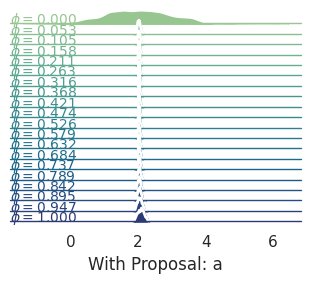

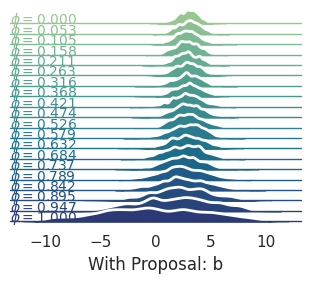

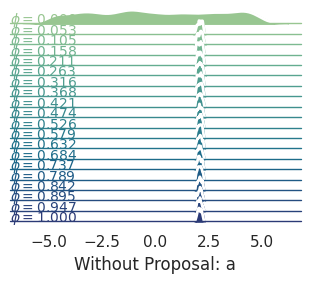

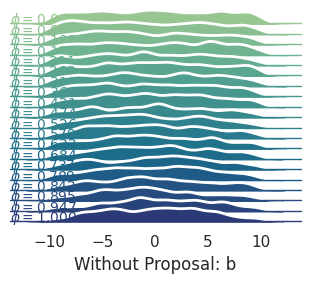

In [8]:
plot_posterior(
    prop_step_list,
    out_file_base="with_proposal",
    figsize=(3.75, 2.75),
)
plot_posterior(
    reg_step_list,
    out_file_base="without_proposal",
    figsize=(3.75, 2.75),
)
